<img src="https://i.imgur.com/48ItoaO.jpg">

<center><h1>One Notebook to Rule 'Em All</h1></center>
<center><h2> "analysis in analysis" deep dive to reveal what makes a notebook win </h2></center>
<center><h2> an Analytics Competition </h2></center>

### Motivation

So far I have participated (actively) in 3 Analytics competitions and I have managed to take prizes in 2. I have seen great work done by amazing people and I've had a bunch of inspiration from some of these notebooks to learn more and understand better.

However, I wanted to take a micro-macro look at these competitions. All of them. See who wins and maybe understand why.

Of course, Kaggle has a list of requirements for every competition, however these are just guidelines. The real competition and the real insights are given by the kagglers.

Hence, I wanted to take a dive into this and better understand - what makes an Analytics Competition notebook great? Can I understand a <span style="background:#4caba4; font-weight:bold; color:black">general recipe</span> and apply it when I myself (and maybe you) participate in such a competition?

> 📌 **Note**: This notebook is the baseline analysis for a presentation I will give at the [Kaggle Days x Z by HP Championship](https://kaggledays.com/championship/) finale.

### ○ Libraries

In [1]:
!pip install pyvis

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 592.8/592.8 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - done
  Created wheel for pyvis: filename=pyvis-0.3.0-py3-none-any.whl size=600250 sha256=4221775758ced7d8c959abdae877486a53fbffaca795f93c86b82e64e6f170fb
  Stored in directory: /root/.cache/pip/wheels/57/74/32/e404e0d76fbb2dc4e3791b821cfae6a69c1a6677ded99dc8b7
Successfully built pyvis


Notebook Color Schemes:


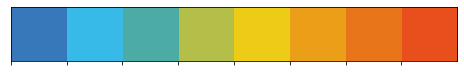

In [2]:
# General Libraries
import os
import re
import wandb
import random
import math
from tqdm import tqdm
from pprint import pprint
from time import time
import itertools
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
from collections import Counter
import operator

# For the Visuals
import networkx as nx
from pyvis.network import Network
import matplotlib as mpl
from matplotlib import cm
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.patches import Rectangle
from IPython.display import display_html
plt.rcParams.update({'font.size': 16})

# For the Wordcloud
from PIL import Image
from wordcloud import WordCloud, STOPWORDS

# Environment check
warnings.filterwarnings("ignore")
os.environ["WANDB_SILENT"] = "true"
CONFIG = {'competition': 'RuleEmAll', '_wandb_kernel': 'aot'}

# Custom colors
class clr:
    S = '\033[1m' + '\033[94m'
    E = '\033[0m'
    
my_colors = ["#3778ba", "#37bae8", "#4caba4", "#b3bf49", 
             "#edcc17", "#eb9f19", "#e9751a", "#e84f1c"]
CMAP1 = ListedColormap(my_colors)

print(clr.S+"Notebook Color Schemes:"+clr.E)
sns.palplot(sns.color_palette(my_colors))
plt.show()

### 🐝 W&B Fork & Run

In order to run this notebook you will need to input your own **secret API key** within the `! wandb login $secret_value_0` line. 

🐝**How do you get your own API key?**

Super simple! Go to **https://wandb.ai/site** -> Login -> Click on your profile in the top right corner -> Settings -> Scroll down to API keys -> copy your very own key (for more info check [this amazing notebook for ML Experiment Tracking on Kaggle](https://www.kaggle.com/ayuraj/experiment-tracking-with-weights-and-biases)).

<center><img src="https://i.imgur.com/fFccmoS.png" width=500></center>

In [3]:
# 🐝 Secrets
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("wandb")

! wandb login $secret_value_0

### ○ Helpers

In [4]:
# === General Functions ===

def stacked_data_prep(df, var, split=False):
    dt = df.groupby(["Place", var])["Name"].count().reset_index()
    if split:
        dt[var] = dt[var].apply(lambda x: [t for t in x.split(", ")])
    dt.columns = ["Place", var, "Frequency"]
    dt = dt.explode(var)
    dt = dt.groupby(["Place", var])["Frequency"].sum().reset_index()
    dt = dt.pivot(index="Place", columns=var, values="Frequency")
    
    dt["Total"] = dt.sum(axis=1)
    for col in dt.columns[:-1]:
        dt[col] = round(dt[col]/dt["Total"], 2)
    dt.drop(columns="Total", inplace=True)
    
    return dt

def jitter(values,j):
    return values + np.random.normal(j,0.1,values.shape)

def similar_color_func(word=None, font_size=None,
                       position=None, orientation=None,
                       font_path=None, random_state=None):
    '''Creates a custom function for the color of the wordcloud.'''
    
    h = 176 # 0 - 360 <- the color hue
    s = 68 # 0-100 <- the color saturation
    l = random_state.randint(30, 50) # 0 - 100 <- gradient
    
    return "hsl({}, {}%, {}%)".format(h, s, l)

def get_name_group(x):
    
    x = x.lower()
    
    if "survey" in x:
        return "Kaggle ML & DS Survey"
    elif "nfl" in x:
        return "NFL Big Data Bowl"
    elif "for good" in x:
        return "DS for Good"
    elif "climate" in x or "environmental" in x:
        return "Environmental Problems"
    else:
        return "Various"

def show_values_on_bars(axs, h_v="v", space=0.4):
    '''Plots the value at the end of the a seaborn barplot.
    axs: the ax of the plot
    h_v: weather or not the barplot is vertical/ horizontal'''
    
    def _show_on_single_plot(ax):
        if h_v == "v":
            for p in ax.patches:
                _x = p.get_x() + p.get_width() / 2
                _y = p.get_y() + p.get_height()
                value = int(p.get_height())
                ax.text(_x, _y, format(value, ','), ha="center") 
        elif h_v == "h":
            for p in ax.patches:
                _x = p.get_x() + p.get_width() + float(space)
                _y = p.get_y() + p.get_height()
                value = int(p.get_width())
                ax.text(_x, _y, format(value, ','), ha="left")

    if isinstance(axs, np.ndarray):
        for idx, ax in np.ndenumerate(axs):
            _show_on_single_plot(ax)
    else:
        _show_on_single_plot(axs)
        
        
# === 🐝 W&B ===
def save_dataset_artifact(run_name, artifact_name, path, data_type="dataset"):
    '''Saves dataset to W&B Artifactory.
    run_name: name of the experiment
    artifact_name: under what name should the dataset be stored
    path: path to the dataset'''
    
    run = wandb.init(project='RuleEmAll', 
                     name=run_name, 
                     config=CONFIG)
    artifact = wandb.Artifact(name=artifact_name, 
                              type=data_type)
    artifact.add_file(path)

    wandb.log_artifact(artifact)
    wandb.finish()
    print("Artifact has been saved successfully.")
    
    
def create_wandb_plot(x_data=None, y_data=None, x_name=None, y_name=None, title=None, log=None, plot="line"):
    '''Create and save lineplot/barplot in W&B Environment.
    x_data & y_data: Pandas Series containing x & y data
    x_name & y_name: strings containing axis names
    title: title of the graph
    log: string containing name of log'''
    
    data = [[label, val] for (label, val) in zip(x_data, y_data)]
    table = wandb.Table(data=data, columns = [x_name, y_name])
    
    if plot == "line":
        wandb.log({log : wandb.plot.line(table, x_name, y_name, title=title)})
    elif plot == "bar":
        wandb.log({log : wandb.plot.bar(table, x_name, y_name, title=title)})
    elif plot == "scatter":
        wandb.log({log : wandb.plot.scatter(table, x_name, y_name, title=title)})
        
        
def create_wandb_hist(x_data=None, x_name=None, title=None, log=None):
    '''Create and save histogram in W&B Environment.
    x_data: Pandas Series containing x values
    x_name: strings containing axis name
    title: title of the graph
    log: string containing name of log'''
    
    data = [[x] for x in x_data]
    table = wandb.Table(data=data, columns=[x_name])
    wandb.log({log : wandb.plot.histogram(table, x_name, title=title)})

In [5]:
# 🐝 Log Cover Photo
run = wandb.init(project='RuleEmAll', name='CoverPhoto', config=CONFIG)
cover = plt.imread("../input/kaggle-analytics-competitions-metadata/procreate cover.jpg")
wandb.log({"cover": wandb.Image(cover)})
wandb.finish()

> 📌 **Note**: !!! All data is for competitions that have already finished and winners have been announced.

**There are 2 tables:**
* `data.csv` - main table, contains all the information by year, competition and winning notebooks
* `requirements.csv` - contains each competition requirements

In [6]:
# Read in data
df = pd.read_csv("../input/kaggle-analytics-competitions-metadata/data.csv")
req = pd.read_csv("../input/kaggle-analytics-competitions-metadata/requirements.csv")
kernels = pd.read_csv("../input/meta-kaggle/Kernels.csv")

# Prep data
df["Group Name"] = df["Name"].apply(lambda x: get_name_group(x))
df["Prize (USD)"] = df["Prize (USD)"].apply(lambda x: int("".join(x.split(","))))
df["Contributor Handles"] = df["Contributor Handles"].apply(lambda x: 
                                                            [t.strip() for t in x.split(",")])

req["Group Name"] = req["Name"].apply(lambda x: get_name_group(x))

In [7]:
# 🐝
save_dataset_artifact(run_name="main_data", 
                      artifact_name="data", 
                      path="../input/kaggle-analytics-competitions-metadata/data.csv",
                      data_type="dataset")

save_dataset_artifact(run_name="requirements", 
                      artifact_name="requirements", 
                      path="../input/kaggle-analytics-competitions-metadata/requirements.csv",
                      data_type="dataset")

Artifact has been saved successfully.
Artifact has been saved successfully.


In [8]:
print(clr.S+"Main Data:"+clr.E, df.shape)
display_html(df.head(3))

print(2*"\n", clr.S+"Requirements:"+clr.E, req.shape)
display_html(req.head(3))

Main Data: (68, 19)


,Year,Name,Competition Link,Prize (USD),Place Info,Place,Notebook Name,Notebook Link,No. Contributors,Contributor Handles,Language,Upvotes,Forks,Versions,Has Schemas,Has Formulas,Visuals Library,GitHub/Repo,Group Name
0,2021,2021 Kaggle Machine Learning & Data Science Su...,https://www.kaggle.com/competitions/kaggle-sur...,10000,NaN,1,Data Science in 2021: Adaptation or Adoption?,https://www.kaggle.com/code/shivamb/data-scien...,2,"[shivamb, khyeh0719]",Python,120.0,77.0,37.0,1.0,1.0,plotly,0.0,Kaggle ML & DS Survey
1,2021,2021 Kaggle Machine Learning & Data Science Su...,https://www.kaggle.com/competitions/kaggle-sur...,5000,NaN,2,How are the 💃 Ladies and the 🎩 Gents doing,https://www.kaggle.com/code/andradaolteanu/how...,1,[andradaolteanu],Python,306.0,131.0,41.0,0.0,0.0,D3.js,0.0,Kaggle ML & DS Survey
2,2021,2021 Kaggle Machine Learning & Data Science Su...,https://www.kaggle.com/competitions/kaggle-sur...,5000,NaN,3,Data Scientists & Analysts: What's the differe...,https://www.kaggle.com/code/spitfire2nd/data-s...,1,[spitfire2nd],Python,98.0,31.0,32.0,0.0,0.0,plotly,0.0,Kaggle ML & DS Survey




 Requirements: (14, 5)


,Year,Name,Link,Evaluation,Group Name
0,2021,2021 Kaggle Machine Learning & Data Science Su...,https://www.kaggle.com/competitions/kaggle-sur...,Composition - Is there a clear narrative threa...,Kaggle ML & DS Survey
1,2021,NFL Big Data Bowl 2022,https://www.kaggle.com/competitions/nfl-big-da...,Innovation:\n\nAre the proposed findings actio...,NFL Big Data Bowl
2,2021,LearnPlatform COVID-19 Impact on Digital Learning,https://www.kaggle.com/competitions/learnplatf...,Clarity (5 pts)\n\nDid the author present a cl...,Various


# 1. What is a Kaggle Analytics Competition?

From what I have seen so far, a **Kaggle Analytics Competition** is a type of comp where the outcome is not as well defined - like using a KPI or a metric and determine based on minimizing or maximizing it who is the winner.

👑 For an Analytics Comp the <span style="background:#4caba4; font-weight:bold; color:black">question is usually open ended</span>, so the teams have the freedom to explore and come up with their own unique solutions for 1 or multiple matters.

These competitions *do not award any medals or ranking points*, however they attract a different kind of "public" let's say than the usual comp.

## 1.1 General Numbers

There have been **14 total competitions** in 4 years. In 2018 NFL "broke the ice" with the first ever Analytics competition on Kaggle. 2019 commerced with 3 more comps and the first ever Kaggle Survey comp, while 2020 was the most *intense* year, with 6 total analytics comps.

<center><img src="https://i.imgur.com/hUfWRrv.jpg" width=800></center>

👑 **Types of Analytics Competitions**:
* **Kaggle ML & DS Survey**: years 2019, 2020, 2021
* **NFL Big Data Bowl**: years 2018, 2019, 2020, 2021 (NFL was the *first* ever hosted analytics competition on the platform)
* **Data Science for Good** (CareerVillage.org & City of LA): in 2019
* **Environmental Problems** (Unlocking Climate Solutions, Environmental Insights Explorer): in 2020
* **Various** - LearnPlatform Covid-19, Smart Water Analytics, March Madness Analytics

In [9]:
# 🐝
run = wandb.init(project='RuleEmAll', name='general', config=CONFIG)

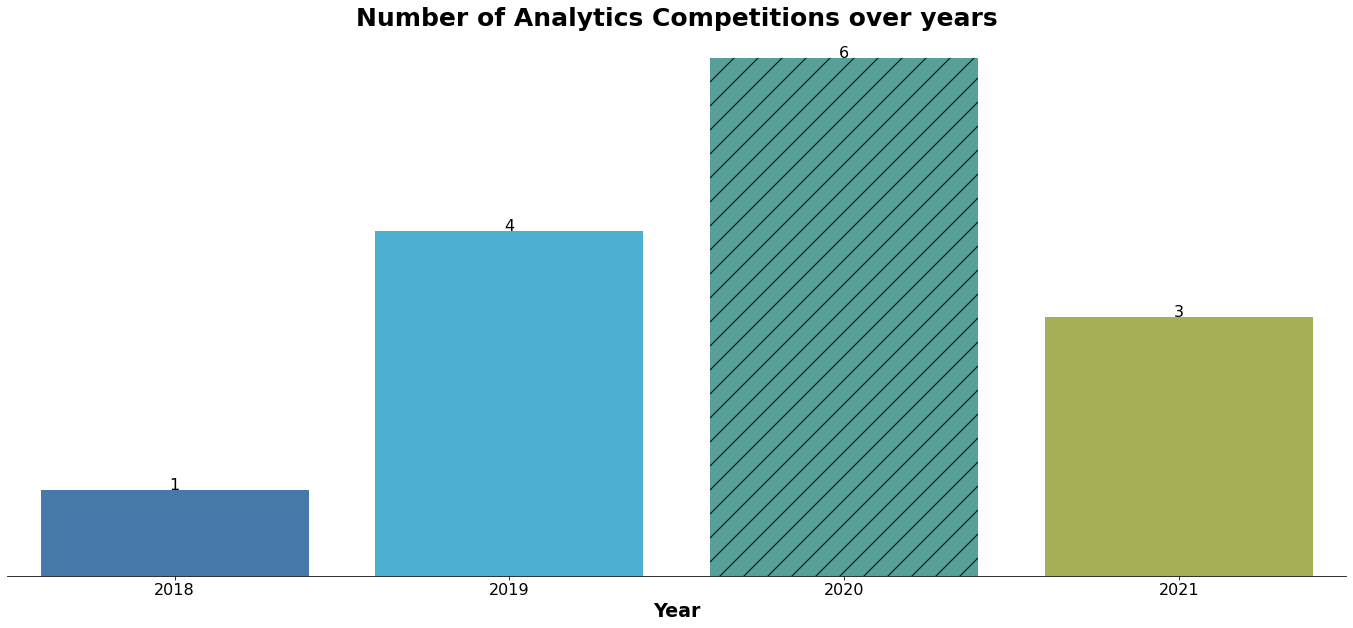

In [10]:
dt = df[["Year", "Name"]].value_counts().reset_index()\
        [["Year"]].value_counts().reset_index()
dt.columns = ["Year", "Number of Competitions"]

# Plot
plt.figure(figsize=(24, 10))
viz = sns.barplot(data=dt, x="Year", y="Number of Competitions", palette=my_colors)
show_values_on_bars(viz, h_v="v", space=0.4)
plt.title("Number of Analytics Competitions over years", weight="bold", size=25)
plt.xlabel("Year", size = 19, weight="bold")
plt.ylabel("")
plt.yticks([])

# Hatch
for i, bar in enumerate(viz.patches):
    hatch = ''
    if i==2:
        hatch = '/'
    bar.set_hatch(hatch)

sns.despine(right=True, top=True, left=True);

In [11]:
# 🐝 Log plots
create_wandb_plot(x_data=dt["Year"],
                  y_data=dt["Number of Competitions"],
                  x_name="Year", 
                  y_name="Count", 
                  title="Number of Analytics Competitions over years",
                  log="years", plot="bar")

## 1.2 Prizes

The total **prize pool** for all 4 years was **\\$633,000**, with an average of \\$10,000 awarded per every winning team. 

The minimum prize was \\$1,000, while the maximum was \\$50,000.

<center><img src="https://i.imgur.com/KaOLYvh.jpg" width=500></center>

Of course, the year with the biggest awarded prize pool as also the year with the highest number of analytics comps.

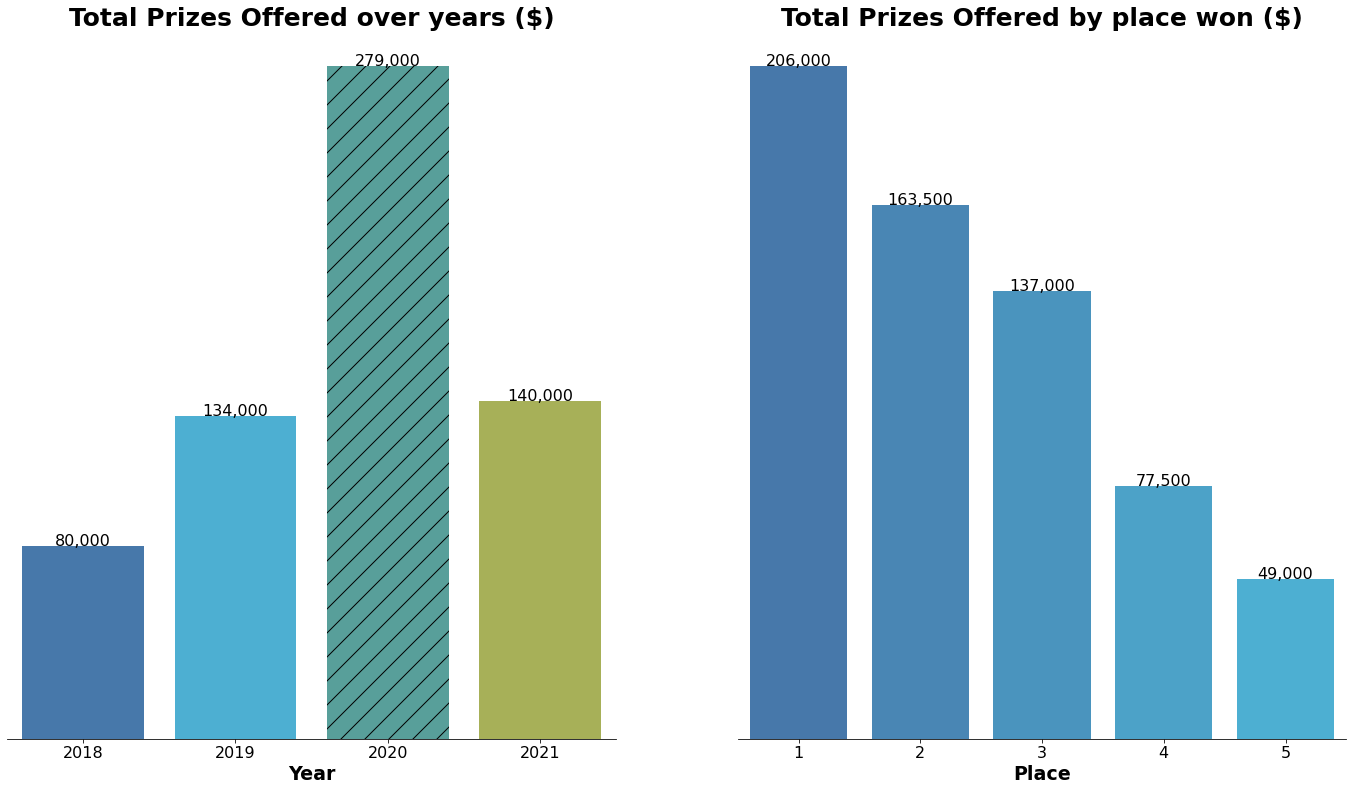

In [12]:
dt1 = df.groupby("Year")["Prize (USD)"].sum().reset_index()
dt2 = df.groupby("Place")["Prize (USD)"].sum().reset_index()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 13))

sns.barplot(data=dt1, x="Year", y="Prize (USD)", palette=my_colors, ax=ax1)
show_values_on_bars(ax1, h_v="v", space=0.4)
ax1.set_title("Total Prizes Offered over years ($)", weight="bold", size=25)
ax1.set_xlabel("Year", size = 19, weight="bold")
ax1.set_ylabel("")
ax1.set_yticks([])

# Hatch
for i, bar in enumerate(ax1.patches):
    hatch = ''
    if i==2:
        hatch = '/'
    bar.set_hatch(hatch)


sns.barplot(data=dt2, x="Place", y="Prize (USD)", ax=ax2,
            palette=sns.blend_palette(colors=[my_colors[0], my_colors[1]], n_colors=5))
show_values_on_bars(ax2, h_v="v", space=0.4)
ax2.set_title("Total Prizes Offered by place won ($)", weight="bold", size=25)
ax2.set_xlabel("Place", size = 19, weight="bold")
ax2.set_ylabel("")
ax2.set_yticks([])

sns.despine(right=True, top=True, left=True);
# plt.savefig('viz.png', dpi=300, transparent=True)

In [13]:
# 🐝 Log plots
create_wandb_plot(x_data=dt1["Year"],
                  y_data=dt1["Prize (USD)"],
                  x_name="Year", 
                  y_name="Total", 
                  title="Total Prizes Offered over years ($)",
                  log="prize", plot="bar")

create_wandb_plot(x_data=dt2["Place"],
                  y_data=dt2["Prize (USD)"],
                  x_name="Year", 
                  y_name="Place", 
                  title="Total Prizes Offered by place won ($)",
                  log="place", plot="bar")

> 🏈 **NFL** is the competition that has the *biggest* prize pool out of all, regardless of the year. These guys don't mess around.

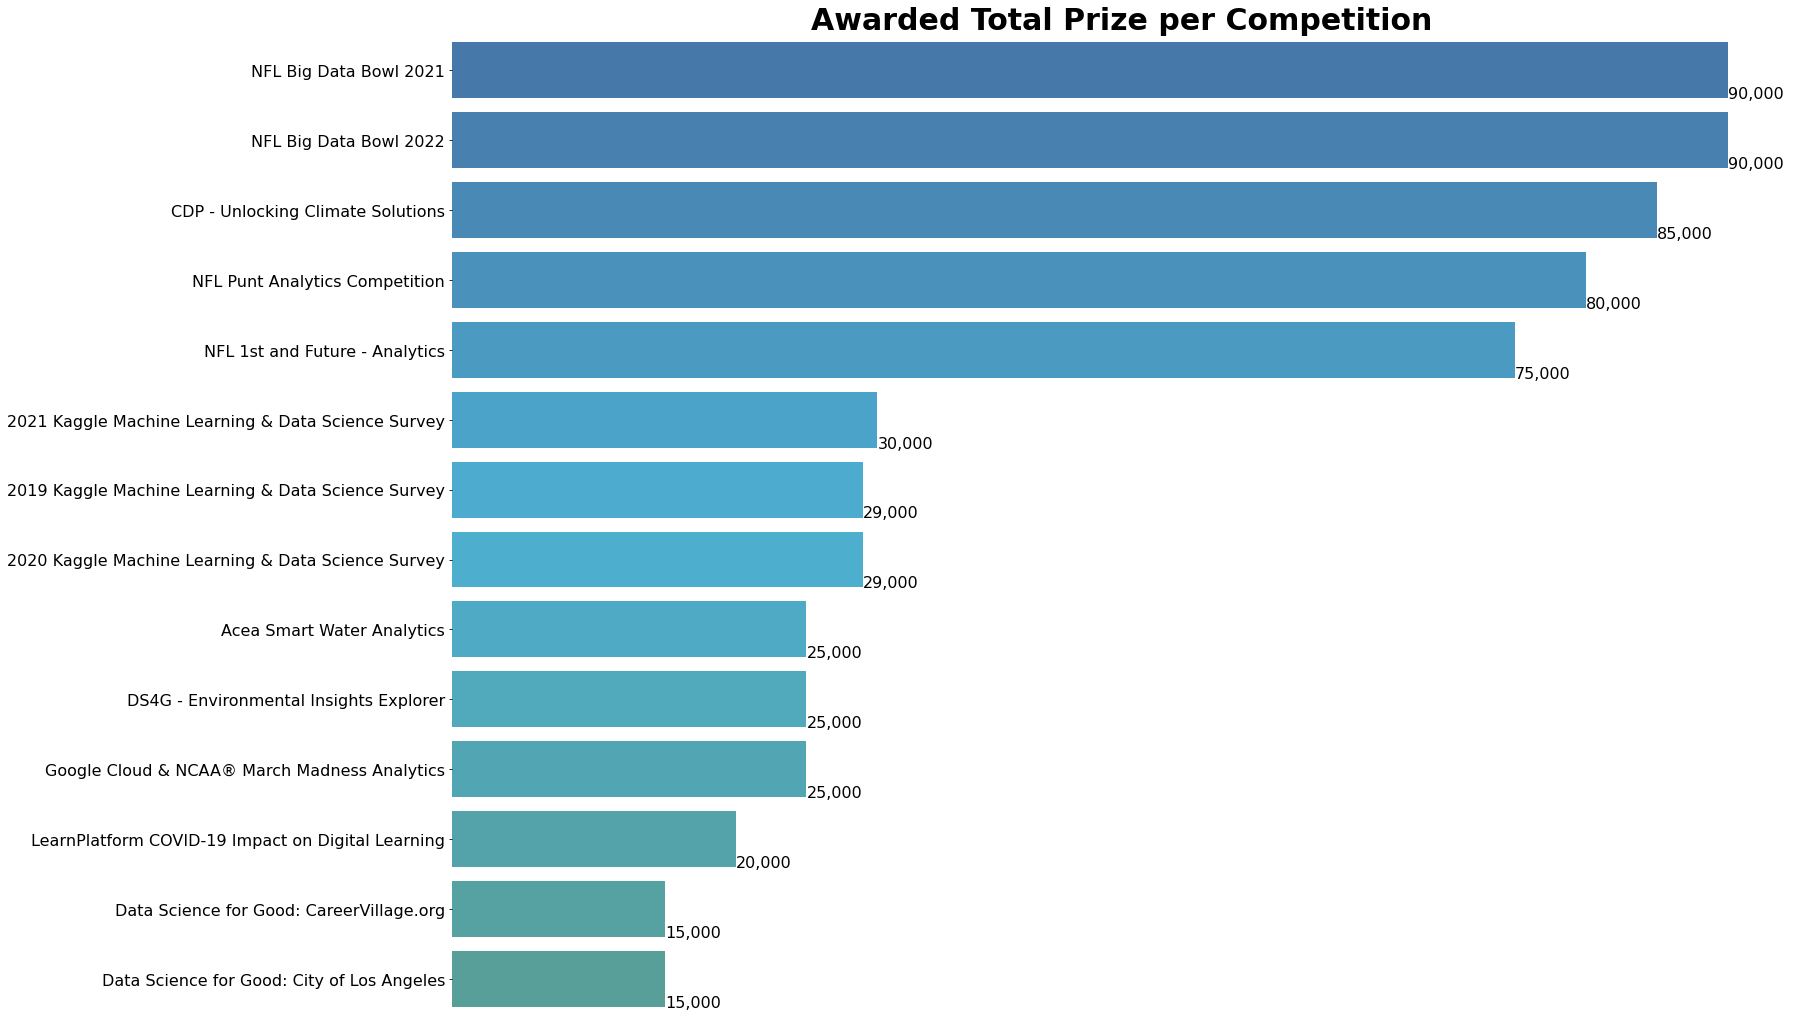

In [14]:
dt = df.groupby("Name")["Prize (USD)"].sum()\
        .reset_index().sort_values("Prize (USD)", 
                                   ascending=False)

# Plot
plt.figure(figsize=(24, 18))

viz = sns.barplot(data=dt, x="Prize (USD)", y="Name",
                  palette=sns.blend_palette(colors=my_colors[:3], n_colors=14))
show_values_on_bars(axs=viz, h_v="h", space=0.4)
plt.title("Awarded Total Prize per Competition", weight="bold", size=30)
plt.ylabel("")
plt.xlabel("")
plt.xticks([])

plt.rcParams.update({'font.size': 22})

# --- FIN ---
sns.despine(right=True, top=True, left=True, bottom=True);
# plt.savefig('viz.png', dpi=300, transparent=True, bbox_inches="tight")

In [15]:
# 🐝 Log plots
create_wandb_plot(x_data=dt["Name"],
                  y_data=dt["Prize (USD)"],
                  x_name="Name", 
                  y_name="(USD)", 
                  title="Awarded Total Prize per Competition ($)",
                  log="name_prize", plot="bar")

## 1.4 Requirements

Each competition has it's own **requirements** - meaning a set of general rules that participants should follow to receive maximum points. These requirements might also contain a general grading rule of the notebooks.

From my experience the rules **should always be read** (because sometimes they contain valuable intel into what the organizers want you to observe), however these guidelines do **not** help you in particular to ... win the comp.

👑 **Here is a condensed list with what the guidelines usually look like**:
* **Composition** | **Clarity** | **Accuracy** - a notebook should be very clear in approach and have consistency throughout. The way the data is used, as well as the conclusions should be accurate and concise.
* **Relevance** | **Reccomendations** | **Applications** | **Game Integrity** - is the notebook providing a viable solution to the organizers? Are the findings relevant and the recommendations applicable within the business? *(especially important and asked for within NFL comps)*
* **Performance** | **Solution Efficacy** - this is relevant only when a certain algorithm or model is required.
* **Originality** | **Innovation** | **Creativity** - the analysis should be bringing something new to the table and should not copy what others have already created beforehand. The solution/conclusion should be inovative and creative, putting the matters into a new perspective.
* **Documentation** - every source should be cited and/or referenced within the analysis.

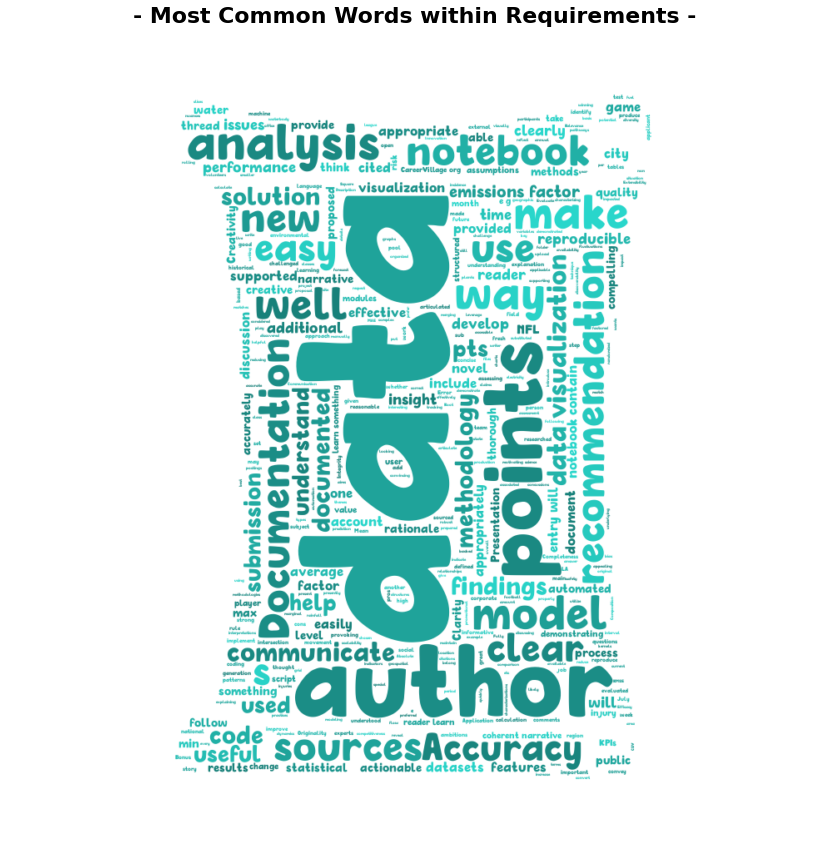

In [16]:
# Get descriptions and convert them to a string
text = req["Evaluation"].unique()
text = " ".join(text)

# Get the mask - the form of the wordcloud
mask = np.array(Image.open('../input/kaggle-analytics-competitions-metadata/scroll.jpg'))

# Create wordcloud object
wc = WordCloud(mask=mask, background_color="white", max_words=2000,
               stopwords=STOPWORDS, max_font_size=256,
               random_state=42, width=mask.shape[1],
               height=mask.shape[0], 
               font_path="../input/hm-fashion-recommender-dataset/MorningRainbow.ttf",
               color_func=similar_color_func)
wc.generate(text)

# Plot
fig = plt.figure(figsize=(15, 15))
plt.title("- Most Common Words within Requirements -",
           size=22, weight="bold")
plt.imshow(wc, interpolation="bilinear")
plt.axis('off')
plt.show()

In [17]:
# 🐝
wandb.finish()

# 2. Contributors

Teaming up is a common behavior on Kaggle and, from what I've seen, yields great results in any type of competition.

👑 However, in **Analytics comps** I've discovered that the pattern is different than the one I'm used to seing:
* People usually team up in NFL competitions - and this happened more heavily in the latest years
* There are people that won **multiple prizes in the same year** for participating in multiple teams. Take for example the NFL 2022: 3 people ([anpatton](https://www.kaggle.com/anpatton), [statsbymichaellopez](https://www.kaggle.com/statsbymichaellopez) and [tombliss](https://www.kaggle.com/tombliss) have participated and won in all 5 winning teams)

<center><img src="https://i.imgur.com/nTwyfoy.png" width=800></center>

* Based on their profile I can strongly now say that **in order to be competitive in NFL you *need* to understand the game on a very deep level** (I know because I've tried and for the life of me, I cannot understand it even on a basic level so ... I surrendered 😅)
* Lately **in NFL the teams are formed of 5 members**, while in other competitions (like the DS Survey and DS for Good) the *"teams" are usually made up by 1 person* (and a maximum of 2 people).

In [18]:
# 🐝
run = wandb.init(project='RuleEmAll', name='contributors', config=CONFIG)

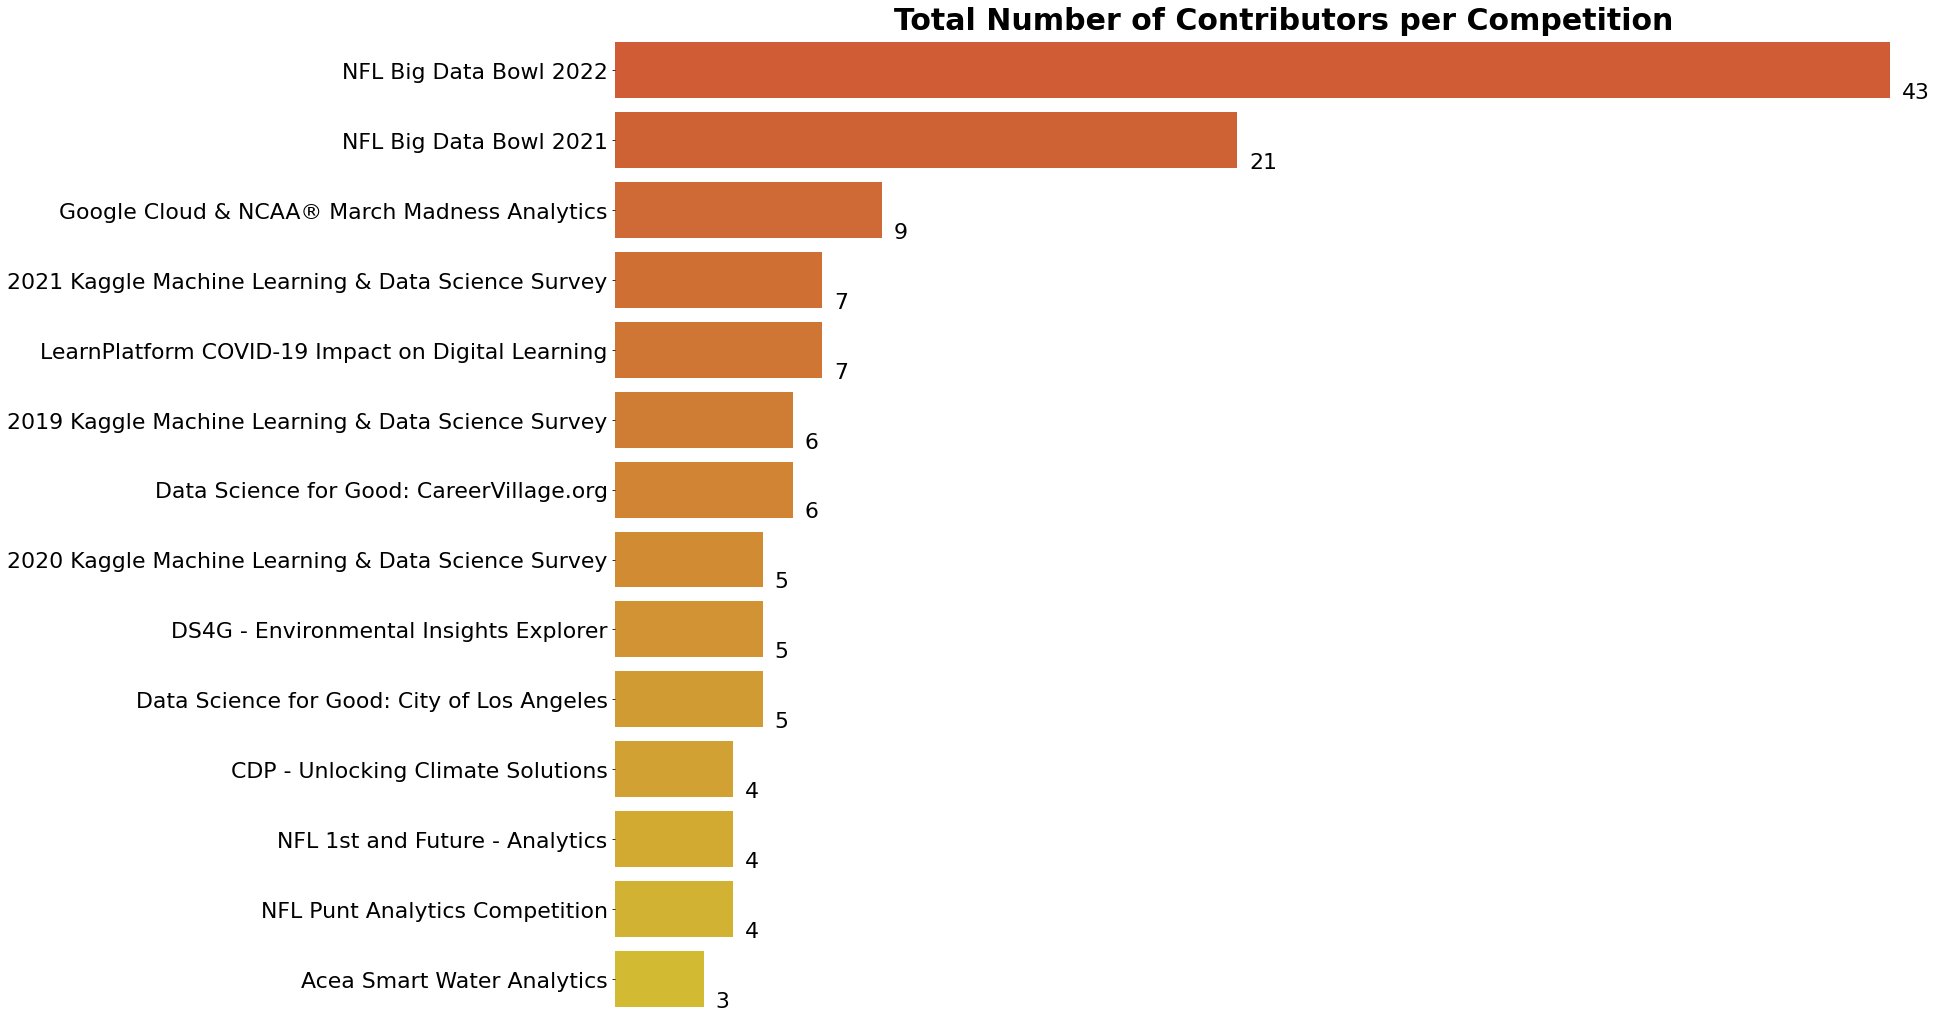

In [19]:
dt = df.groupby("Name")["No. Contributors"].sum().reset_index()\
        .sort_values("No. Contributors", ascending=False)

# Plot
plt.figure(figsize=(24, 18))

viz = sns.barplot(data=dt, x="No. Contributors", y="Name",
                  palette=sns.blend_palette(colors=my_colors[4:][::-1], n_colors=14))
show_values_on_bars(viz, h_v="h", space=0.4)
plt.title("Total Number of Contributors per Competition", weight="bold", size=30)
plt.ylabel("")
plt.xlabel("")
plt.xticks([])

plt.rcParams.update({'font.size': 22})

# --- FIN ---
sns.despine(right=True, top=True, left=True, bottom=True);
# plt.savefig('viz.png', dpi=300, transparent=True, bbox_inches="tight")

In [20]:
# 🐝 Log plots
create_wandb_plot(x_data=dt["No. Contributors"],
                  y_data=dt["Name"],
                  x_name="No. Contributors", 
                  y_name="Name", 
                  title="Total Number of Contributors per Competition",
                  log="contrib_total", plot="bar")

## 2.1 Most wins per User

* Of course, again, our 3 dudes from NFL have the highest winning rate out of all - 8 total wins 🔥
* [artvolgin](https://www.kaggle.com/artvolgin), [katemelianova](https://www.kaggle.com/katemelianova) and [iamleonie](https://www.kaggle.com/iamleonie) have 4 wins in total so far - leonie & katemelianova have won multiple competitions on various topics
* [shivamb](https://www.kaggle.com/shivamb) and [jpmiller](https://www.kaggle.com/jpmiller) have 3 total wins - both are 1st place winners of the Kaggle Data Science Survey
* although I do not keep track of this within the data, from what I have noticed while gathering it is that the percentage of *women* participating in the analytics competitions is **higher** than the usual comps - which is freaking fantastic ♥

<center><img src="https://i.imgur.com/LPoWLiC.png" width=800></center>

In [21]:
dt = df.explode("Contributor Handles")["Contributor Handles"].value_counts().reset_index()
dt.columns = ["Username", "Wins"]
print(clr.S+"Total Unique Winners:"+clr.E, dt["Username"].nunique())
wandb.log({"Total Unique Winners": dt["Username"].nunique()})

Total Unique Winners: 84


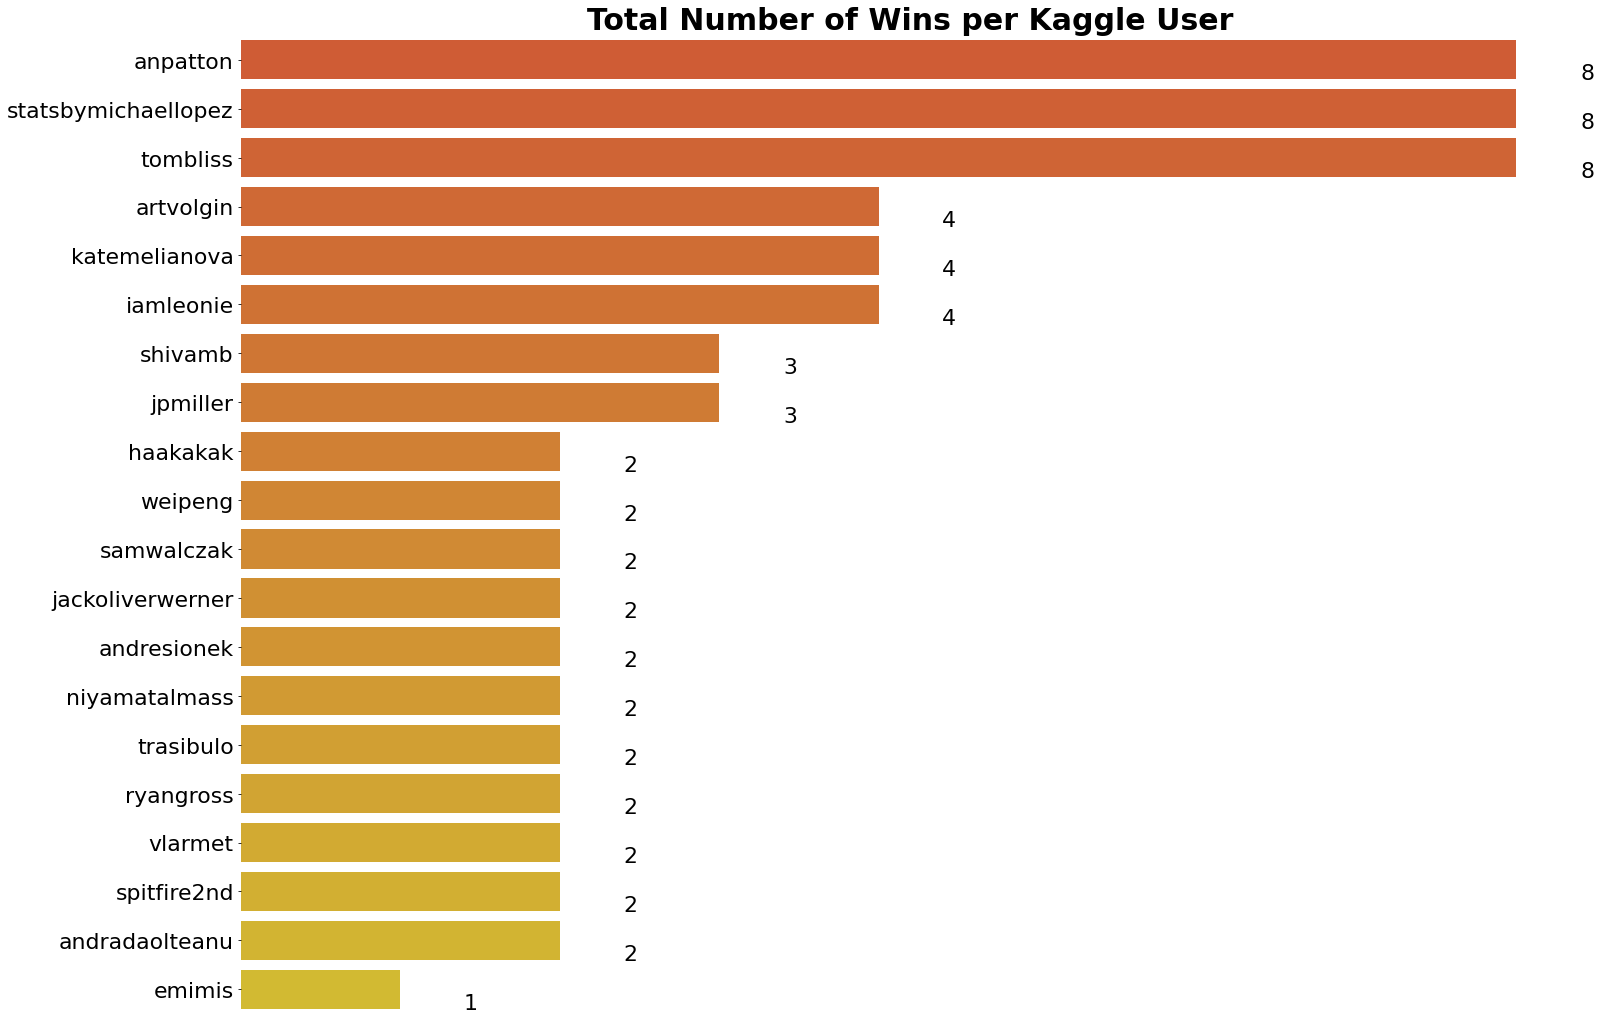

In [22]:
# Plot
plt.figure(figsize=(24, 18))

viz = sns.barplot(data=dt.head(20), x="Wins", y="Username",
                  palette=sns.blend_palette(colors=my_colors[4:][::-1], n_colors=20))
show_values_on_bars(viz, h_v="h", space=0.4)
plt.title("Total Number of Wins per Kaggle User", weight="bold", size=30)
plt.ylabel("")
plt.xlabel("")
plt.xticks([])

plt.rcParams.update({'font.size': 22})

# --- FIN ---
sns.despine(right=True, top=True, left=True, bottom=True);
# plt.savefig('viz.png', dpi=300, transparent=True, bbox_inches="tight")

In [23]:
# 🐝 Log plots
create_wandb_plot(x_data=dt["Username"],
                  y_data=dt["Wins"],
                  x_name="Username", 
                  y_name="Wins", 
                  title="Total Number of Wins per Kaggle User",
                  log="wins_kaggler", plot="bar")

## 2.2 Are the winners specialized?

I also wanted to see if a person competes randomly in *any* analytics competition or if they **specialize** on a particular problem.

👑 And the answer would be **yes**. Our 3 NFL dudes compete only in NFL comps, while Leonie, Shivam, or Spitfire2nd compete a lot (and win) in Kaggle DS Survey comp. Artvolgin competes in Environmental comps.

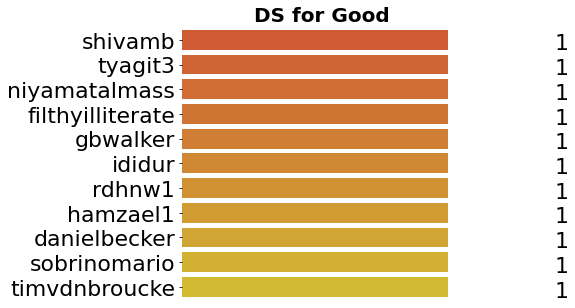

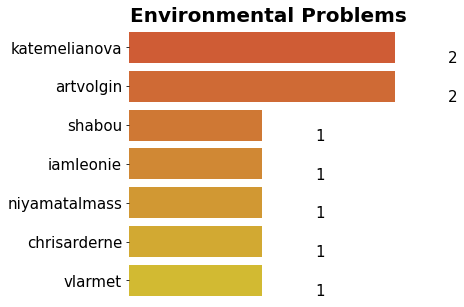

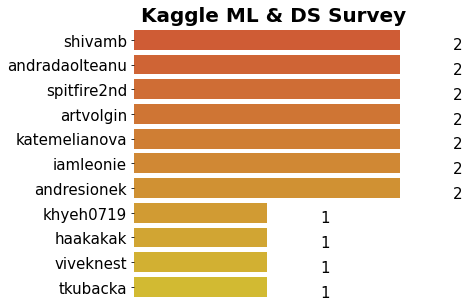

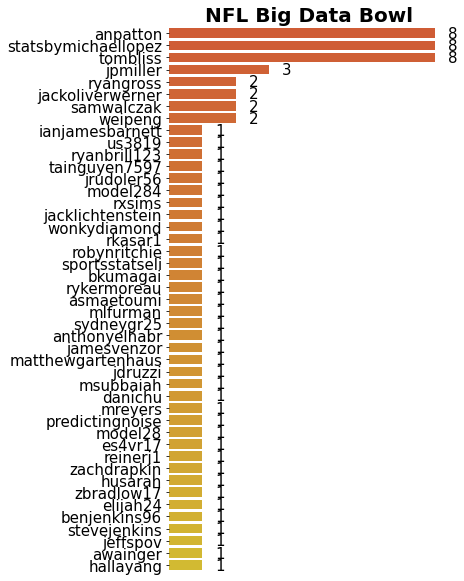

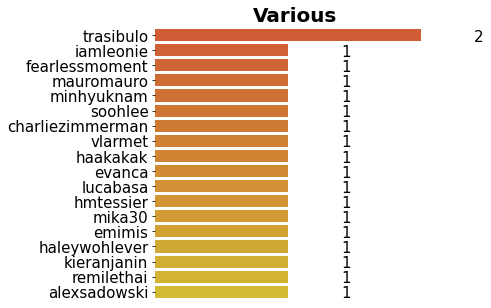

In [24]:
dt = df.groupby("Group Name").agg({"Contributor Handles" : 'sum'}).reset_index()
dt["Contributor Handles"] = dt["Contributor Handles"]\
                            .apply(lambda x: dict(sorted(Counter(x).items(), 
                                                         key=operator.itemgetter(1),
                                                         reverse=True)))
plot_sizes = [5, 5, 5, 10, 5]

for i in range(len(dt)):
    title = dt.loc[i, "Group Name"]
    handles_dict = dt.loc[i, "Contributor Handles"]
    handles_df = pd.DataFrame(handles_dict.items(),
                              columns=["Username", "Activity"])
    
    # Plot
    plt.figure(figsize=(5, plot_sizes[i]))
    viz = sns.barplot(data=handles_df, x="Activity", y="Username",
                      palette=sns.blend_palette(colors=my_colors[4:][::-1], 
                                                n_colors=len(handles_df)))
    show_values_on_bars(viz, h_v="h", space=0.4)
    plt.title(title, weight="bold", size=20)
    plt.ylabel("")
    plt.xlabel("")
    plt.xticks([])

    plt.rcParams.update({'font.size': 15})
    sns.despine(right=True, top=True, left=True, bottom=True);
    plt.show()
    print("\n")

## 2.3 Winners network

<center><img src="https://i.imgur.com/aUTpF5g.png" width=700></center>


In [25]:
# From groups bugger than 1 create pairs
pairs = list(itertools.chain(
    *list(df[df["No. Contributors"]>=2]["Contributor Handles"]\
          .apply(lambda l: list(itertools.combinations(l, r=2))))))

pairs_df = pd.DataFrame(pairs, 
                        columns=["Source", "Target"])
pairs_df = pairs_df[["Source", "Target"]].value_counts().reset_index()
pairs_df.columns = ["Source", "Target", "Weight"]

# Create Nodes Data
nodes = list(pairs_df["Source"].unique())
interm = list(pairs_df["Target"].unique())

nodes = list(set(nodes+interm))
nodes = pd.DataFrame({"id": range(len(nodes)),
                      "label": nodes})

# Create edges data
edges = pairs_df.merge(nodes, left_on="Source",
                       right_on="label").drop(columns=["Source","label"])
edges = edges.merge(nodes, left_on="Target",
                    right_on="label").drop(columns=["Target","label"])
edges.columns = ["weight", "from", "to"]

nodes.to_csv("nodes.csv", index=False)
edges.to_csv("edges.csv", index=False)

In [26]:
# === pyvis ===

pairs_net = Network(height="750px", width="100%", bgcolor="#222222", font_color="white")
# set the physics layout of the network
pairs_net.barnes_hut(gravity=-80000, central_gravity=0.3, 
                     spring_length=10, spring_strength=0.002, damping=0.09, overlap=0)

sources = pairs_df['Source']
targets = pairs_df['Target']
weights = pairs_df['Weight']
edge_data = zip(sources, targets, weights)

for e in edge_data:
    src = e[0]
    dst = e[1]
    w = e[2]

    pairs_net.add_node(src, src, title=src)
    pairs_net.add_node(dst, dst, title=dst)
    pairs_net.add_edge(src, dst, value=w, title=w)
    
neighbor_map = pairs_net.get_adj_list()

# add neighbor data to node hover data
for node in pairs_net.nodes:
    node["title"] += " Neighbors: " + " | ".join(neighbor_map[node["id"]])
    node["value"] = len(neighbor_map[node["id"]])

In [27]:
pairs_net.show("pairs.html")

## 2.4 Is the number of your team dictating if you win?

👑 I would say **no**.

By looking at the general patterns between places 1 and 5 *I do not notice any strong behavior* - there are many "teams" that won 1st place with only a couple (or even less) team members - but that is also true for places 4 and 5.

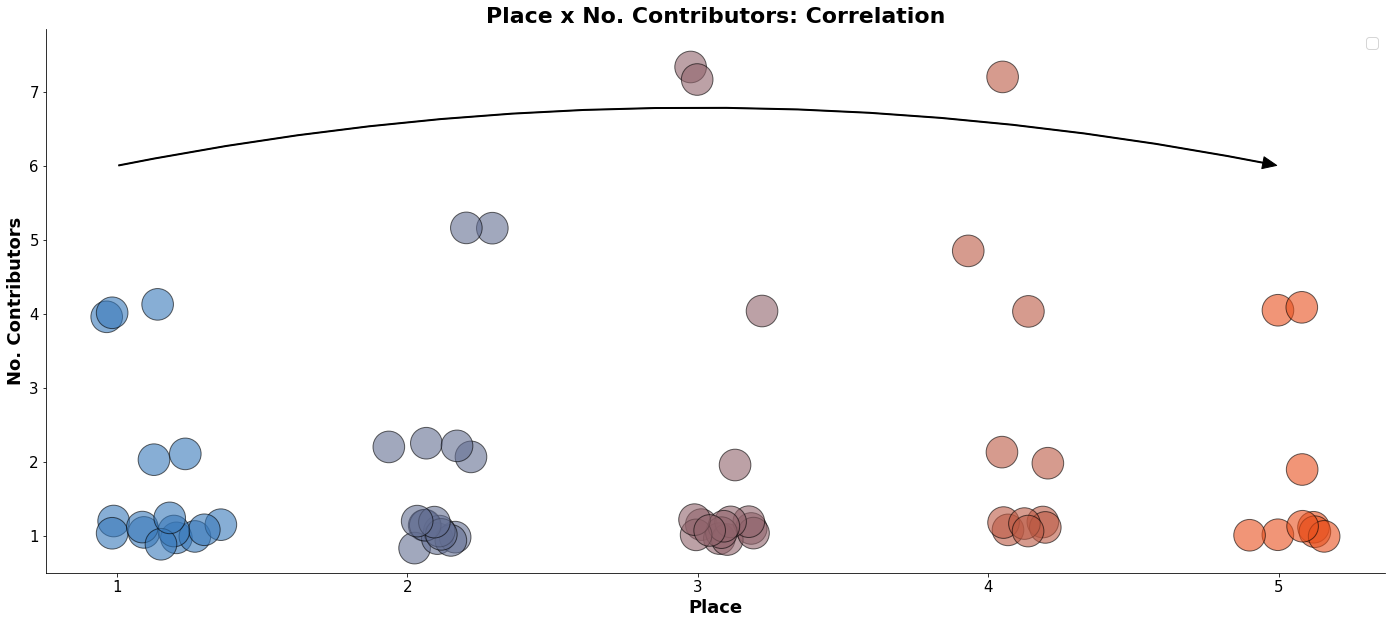

In [28]:
plt.figure(figsize=(24, 10))

sns.scatterplot(x=jitter(df["Place"], 0.1), y=jitter(df["No. Contributors"], 0.1), 
                size=df["Place"], alpha=0.6, sizes=(1000, 1000),
                hue=df["Place"],
                palette=sns.blend_palette(colors=[my_colors[0], my_colors[7]], n_colors=5),
                edgecolor="black", linewidth=1)

plt.title("Place x No. Contributors: Correlation", weight="bold", size=22)
plt.ylabel("No. Contributors", size = 18, weight="bold")
plt.xlabel("Place", size = 18, weight="bold")

# Arrow
style = "Simple, tail_width=1, head_width=12, head_length=14"
kw = dict(arrowstyle=style, color="black")
arrow = patches.FancyArrowPatch((1, 6), (5, 6),
                             connectionstyle="arc3,rad=-.10", **kw)
plt.gca().add_patch(arrow)

# --- FIN ---
sns.despine(right=True, top=True, left=False)
plt.legend([]);
# plt.savefig('viz.png', dpi=300, transparent=True, bbox_inches="tight")

In [29]:
# 🐝 Log plots
create_wandb_plot(x_data=jitter(df["Place"], 0.1),
                  y_data=jitter(df["No. Contributors"], 0.1),
                  x_name="Place", 
                  y_name="No. Contributors", 
                  title="Place x No. Contributors: Correlation",
                  log="coords_corr", plot="scatter")

In [30]:
# 🐝
wandb.finish()

# 3. How do they win?

Now that we've looked at the contributors and how they behave, we can start analyzing what did they use or do in order to succeed.

In [31]:
# 🐝
run = wandb.init(project='RuleEmAll', name='recipes', config=CONFIG)

## 3.1 Finished Place x Upvotes

Some believe that if their notebook got a very low upvote count it means that they did a bad job or that the notebook is not valuable.

Although upvotes from the community can represent a **boost** in confidence, they do not guarantee the quality of a notebook.

<center><img src="https://i.imgur.com/pBBV5kX.png" width=400></center>

👑 So the answer would be **no** - upvotes do not represent higher chances to win. Many *notebooks in the first 3 places have very low vote count* - and there are notebooks with a high vote count that haven't even made it in the prize pool altogether, as upvotes are rather based on the community's opinion, so the judges are not really influenced by it.

So:
* if you have a very low upvote count => doesn't mean you won't win.
* if you have a high upvote count => doesn't mean you will win.

👑 As a side note though, the mean upvotes within the Kaggle Analytics Comps is **much higher** than the average upvote within the overall Kaggle Community.

Mean Upvotes: 52 
Min Upvotes: 2 
Max Upvotes: 354


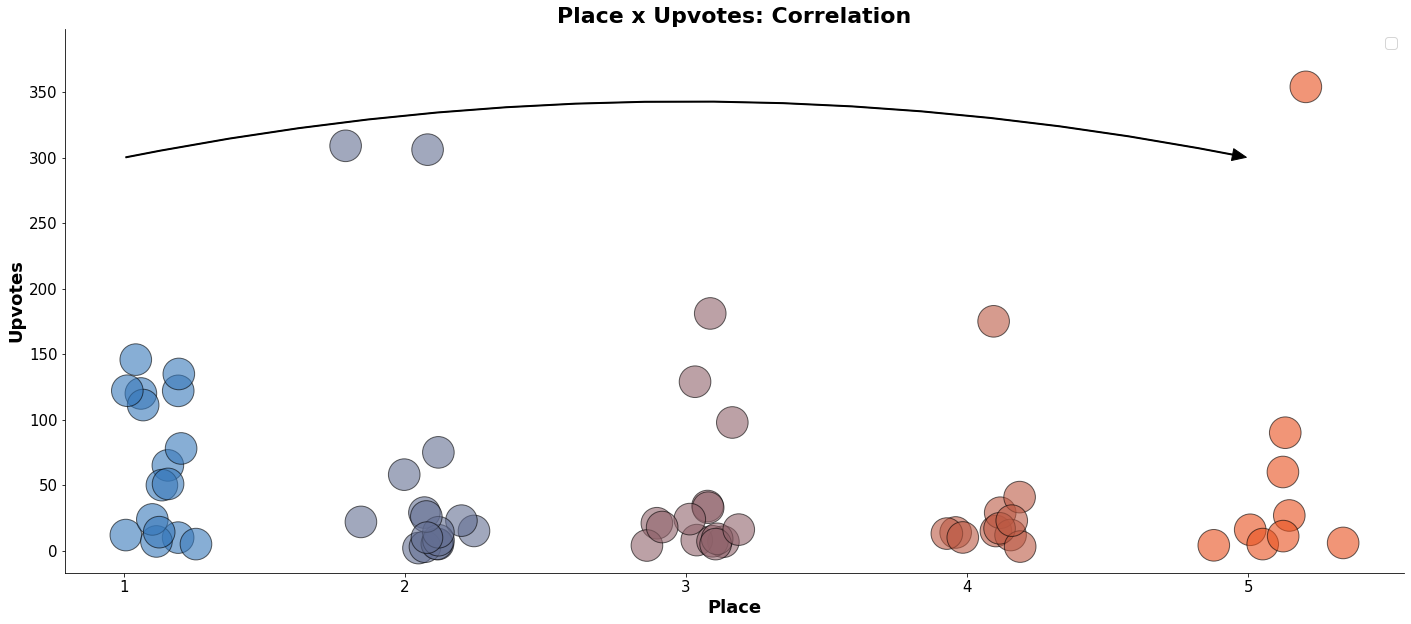

In [32]:
feature = "Upvotes"

print(clr.S+f"Mean {feature}:"+clr.E, round(df[feature].mean()), "\n"+
      clr.S+f"Min {feature}:"+clr.E, round(df[feature].min()), "\n"+
      clr.S+f"Max {feature}:"+clr.E, round(df[feature].max()))

plt.figure(figsize=(24, 10))

sns.scatterplot(x=jitter(df["Place"], 0.1), y=jitter(df[feature], 0.1), 
                size=df["Place"], alpha=0.6, sizes=(1000, 1000),
                hue=df["Place"],
                palette=sns.blend_palette(colors=[my_colors[0], my_colors[7]], n_colors=5),
                edgecolor="black", linewidth=1)

plt.title(f"Place x {feature}: Correlation", weight="bold", size=22)
plt.ylabel(feature, size = 18, weight="bold")
plt.xlabel("Place", size = 18, weight="bold")

# Arrow
style = "Simple, tail_width=1, head_width=12, head_length=14"
kw = dict(arrowstyle=style, color="black")
arrow = patches.FancyArrowPatch((1, 300), (5, 300),
                             connectionstyle="arc3,rad=-.10", **kw)
plt.gca().add_patch(arrow)

# --- FIN ---
sns.despine(right=True, top=True, left=False)
plt.legend([]);
# plt.savefig('viz.png', dpi=300, transparent=True, bbox_inches="tight")

Mean Upvotes: 4 
Min Upvotes: 0 
Max Upvotes: 12647


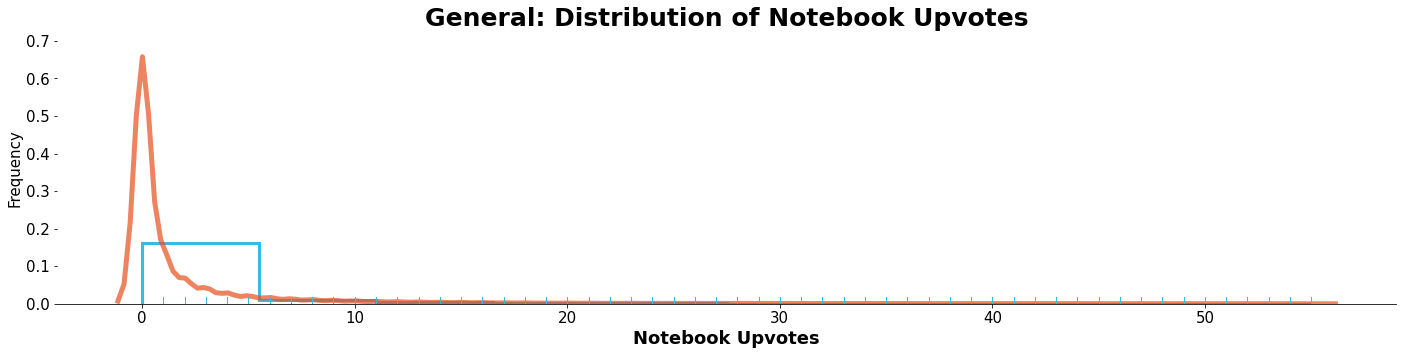

In [33]:
print(clr.S+f"Mean {feature}:"+clr.E, round(kernels["TotalVotes"].mean()), "\n"+
      clr.S+f"Min {feature}:"+clr.E, round(kernels["TotalVotes"].min()), "\n"+
      clr.S+f"Max {feature}:"+clr.E, round(kernels["TotalVotes"].max()))

plt.figure(figsize=(24, 5))
q = kernels["TotalVotes"].quantile(0.99)

sns.distplot(kernels[kernels["TotalVotes"]<q]["TotalVotes"],
             rug=True, bins=10,
             rug_kws={"color": my_colors[1]},
             kde_kws={"color": my_colors[-1], "lw": 5, "alpha": 0.7},
             hist_kws={"histtype": "step", "linewidth": 3, "alpha": 1, "color": my_colors[1]}
            )

plt.title(f"General: Distribution of Notebook {feature}", weight="bold", size=25)
plt.xlabel(f"Notebook {feature}", size = 18, weight="bold")
plt.ylabel("Frequency")

sns.despine(right=True, top=True, left=True);

In [34]:
# 🐝 Log plots
create_wandb_plot(x_data=jitter(df["Place"], 0.1),
                  y_data=jitter(df[feature], 0.1),
                  x_name="Place", 
                  y_name=feature, 
                  title=f"Place x {feature}: Correlation",
                  log=f"{feature}_corr", plot="scatter")

## 3.2 Finished Place x Forks

👑 I was also curious to see if the *forks* show any different than the *upvotes* - and I believe they do. There are many **more forks for the top winning notebooks**, *however* this must be **after** the notebooks have already won (and the community started to get interested).

Mean Forks: 41 
Min Forks: 1 
Max Forks: 208


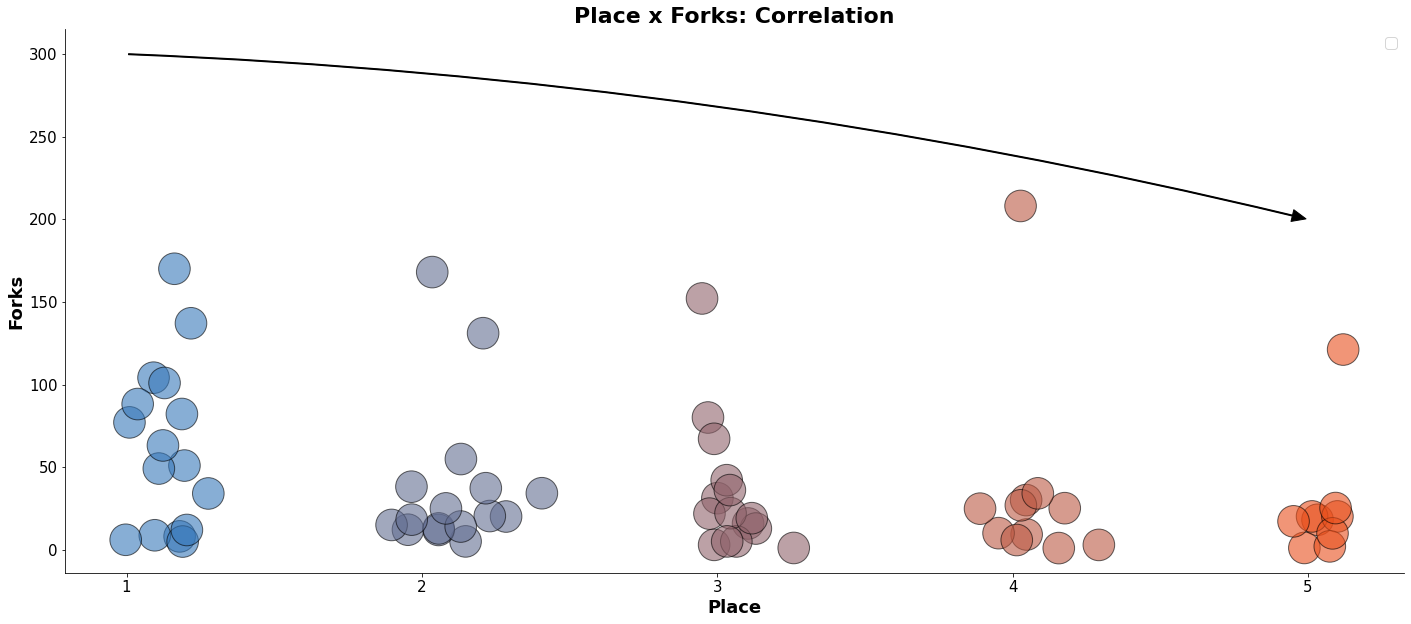

In [35]:
feature = "Forks"

print(clr.S+f"Mean {feature}:"+clr.E, round(df[feature].mean()), "\n"+
      clr.S+f"Min {feature}:"+clr.E, round(df[feature].min()), "\n"+
      clr.S+f"Max {feature}:"+clr.E, round(df[feature].max()))

plt.figure(figsize=(24, 10))

sns.scatterplot(x=jitter(df["Place"], 0.1), y=jitter(df[feature], 0.1), 
                size=df["Place"], alpha=0.6, sizes=(1000, 1000),
                hue=df["Place"],
                palette=sns.blend_palette(colors=[my_colors[0], my_colors[7]], n_colors=5),
                edgecolor="black", linewidth=1)

plt.title(f"Place x {feature}: Correlation", weight="bold", size=22)
plt.ylabel(feature, size = 18, weight="bold")
plt.xlabel("Place", size = 18, weight="bold")

# Arrow
style = "Simple, tail_width=1, head_width=12, head_length=14"
kw = dict(arrowstyle=style, color="black")
arrow = patches.FancyArrowPatch((1, 300), (5, 200),
                             connectionstyle="arc3,rad=-.05", **kw)
plt.gca().add_patch(arrow)

# --- FIN ---
sns.despine(right=True, top=True, left=False)
plt.legend([]);
# plt.savefig('viz.png', dpi=300, transparent=True, bbox_inches="tight")

In [36]:
# 🐝 Log plots
create_wandb_plot(x_data=jitter(df["Place"], 0.1),
                  y_data=jitter(df[feature], 0.1),
                  x_name="Place", 
                  y_name=feature, 
                  title=f"Place x {feature}: Correlation",
                  log=f"{feature}_corr", plot="scatter")

## 3.3 Finished Place x Versions

The versions I would say could represent how *hard* somebody worked on their notebook. Although versions do not necessarly represent a lot of code or valuable *work* was added, they still show the level of intensity in which somebody prepared for the competition.

<center><video src="https://i.imgur.com/cVOqIBF.mp4" width=200 controls></center>

👑 I would say that the majority of people are working **at least 1 month** constantly for a winning notebook. Some of the notebooks that have very low version count still have an attached **Git Repo** to them, which means that a good portion (or all) was done outside the Kaggle environment.

Mean Versions: 23 
Min Versions: 1 
Max Versions: 78


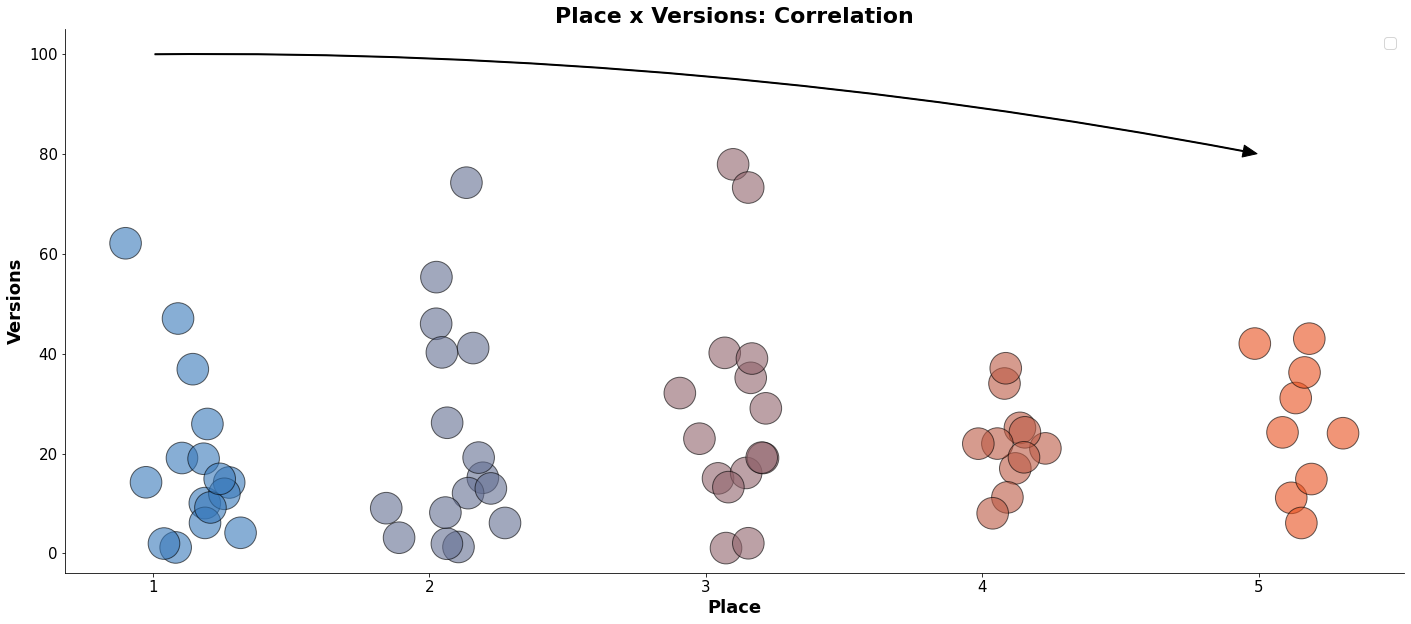

In [37]:
feature = "Versions"

print(clr.S+f"Mean {feature}:"+clr.E, round(df[feature].mean()), "\n"+
      clr.S+f"Min {feature}:"+clr.E, round(df[feature].min()), "\n"+
      clr.S+f"Max {feature}:"+clr.E, round(df[feature].max()))

plt.figure(figsize=(24, 10))

sns.scatterplot(x=jitter(df["Place"], 0.1), y=jitter(df[feature], 0.1), 
                size=df["Place"], alpha=0.6, sizes=(1000, 1000),
                hue=df["Place"],
                palette=sns.blend_palette(colors=[my_colors[0], my_colors[7]], n_colors=5),
                edgecolor="black", linewidth=1)

plt.title(f"Place x {feature}: Correlation", weight="bold", size=22)
plt.ylabel(feature, size = 18, weight="bold")
plt.xlabel("Place", size = 18, weight="bold")

# Arrow
style = "Simple, tail_width=1, head_width=12, head_length=14"
kw = dict(arrowstyle=style, color="black")
arrow = patches.FancyArrowPatch((1, 100), (5, 80),
                             connectionstyle="arc3,rad=-.05", **kw)
plt.gca().add_patch(arrow)

# --- FIN ---
sns.despine(right=True, top=True, left=False)
plt.legend([]);
# plt.savefig('viz.png', dpi=300, transparent=True, bbox_inches="tight")

In [38]:
# 🐝 Log plots
create_wandb_plot(x_data=jitter(df["Place"], 0.1),
                  y_data=jitter(df[feature], 0.1),
                  x_name="Place", 
                  y_name=feature, 
                  title=f"Place x {feature}: Correlation",
                  log=f"{feature}_corr", plot="scatter")

## 3.4 Finished Place x Languages

👑 Python has the lead, however there is a **higher preference** for R and R Markdown than what we usually see in the community *(in the Kaggle Survey 2021 the responses suggested that ~80% of users prefere Python and only ~20% also use R)*.

**To be noted** that a few of the winning notebooks were *written* in R or R Markdown, but the *entire anaysis was done on GitHub* using both R and Python.

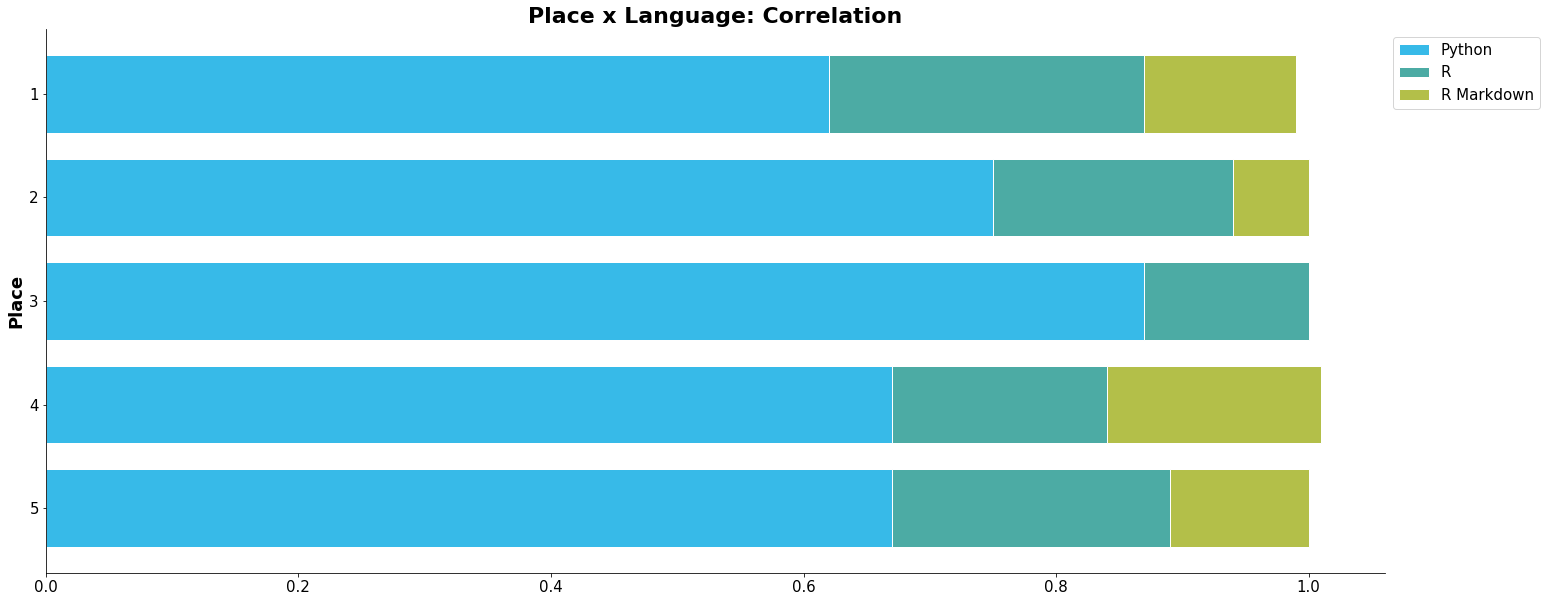

In [39]:
feature = "Language"

dt = stacked_data_prep(df, var=feature, split=True)

dt.plot(kind="barh", stacked=True, title="stacked", figsize=(24, 10),
        color = my_colors[1:], xlabel="Place", edgecolor='white', width=0.75)
plt.title(f"Place x {feature}: Correlation", weight="bold", size=22)
plt.ylabel("Place", size = 18, weight="bold")

ax = plt.gca()
ax.invert_yaxis()

sns.despine()

plt.legend(loc='upper left', bbox_to_anchor=(1,1), ncol=1);
# plt.savefig('viz.png', dpi=300, transparent=True, bbox_inches="tight")

## 3.5 Finished Place x Visuals Libraries

👑 Hush, there are a few things to unpack here:
* `matplotlib` & `seaborn` - the classic duo and the most used, especially in the notebooks that are more concentrated towards towards giving a solution rather than on story telling (although there is beautiful storytelling to be told with these too, like in [A story told through a heatmap](https://www.kaggle.com/code/tkubacka/a-story-told-through-a-heatmap/notebook) by Teresa)
* `plotly` - is when you dress to impress, this library is heavily used too (here is a beautiful example from the winning notebook from the Kaggle DS Survey in 2021 - [Data Science in 2021 : Adaptation or Adoption?](https://www.kaggle.com/code/shivamb/data-science-in-2021-adaptation-or-adoption/notebook))
* `ggplot` & `Shiny` - in here `ggplot` represents many other `gg` libraries (`gganimate` + `ggmap` + `igraph` etc.) that I have incorporated in only this one. Shiny is here too because it's a great addition in R when you want to create interactive Dashboards (like in this example [Weighted Assessment of Defender Effectiveness](https://www.kaggle.com/code/asmaetoumi/weighted-assessment-of-defender-effectiveness/notebook))
* `D3` - this one was used only twice - by one of my dearest kagglers Schubert, who has also introduced this tool to me in his winning notebook [Enthusiast to Data Professional - What changes?](https://www.kaggle.com/code/spitfire2nd/enthusiast-to-data-professional-what-changes/notebook) and by me in [How are the 💃Ladies and the 🎩Gents doing?](https://www.kaggle.com/code/andradaolteanu/how-are-the-ladies-and-the-gents-doing/notebook). D3 is absolutely incredible and super versetile, so I could safely say it gives an edge and some bonus points for novelty and originality.

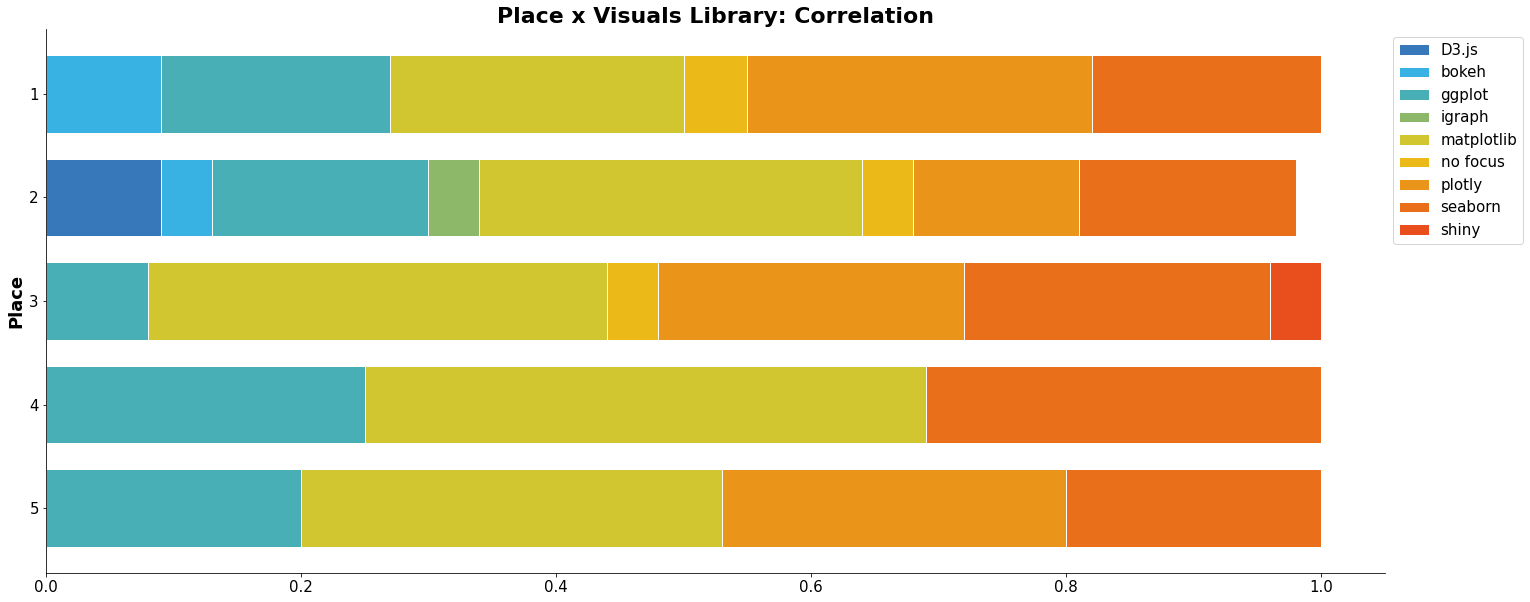

In [40]:
feature = "Visuals Library"

dt = stacked_data_prep(df, var=feature, split=True)

dt.plot(kind="barh", stacked=True, title="stacked", figsize=(24, 10),
        color = sns.blend_palette(colors=my_colors, n_colors=9), xlabel="Place", edgecolor='white', width=0.75)
plt.title(f"Place x {feature}: Correlation", weight="bold", size=22)
plt.ylabel("Place", size = 18, weight="bold")

ax = plt.gca()
ax.invert_yaxis()

sns.despine()

plt.legend(loc='upper left', bbox_to_anchor=(1,1), ncol=1);
# plt.savefig('viz.png', dpi=300, transparent=True, bbox_inches="tight")

## 3.6 Finished Place x "Has Schemas"

A schema is any helping visual within a notebook that acts as a guide to the viewer to **better understand what the author is trying to convey**.

I am a huge fan of schemas, because people are *visual*, meaning that we understand the majority of information while we see it, not while hearing or reading it.

👑 And the graph really shows that **yes**, the vast majority of the notebooks that ended on the 1st place have at least 1 scheme within them.

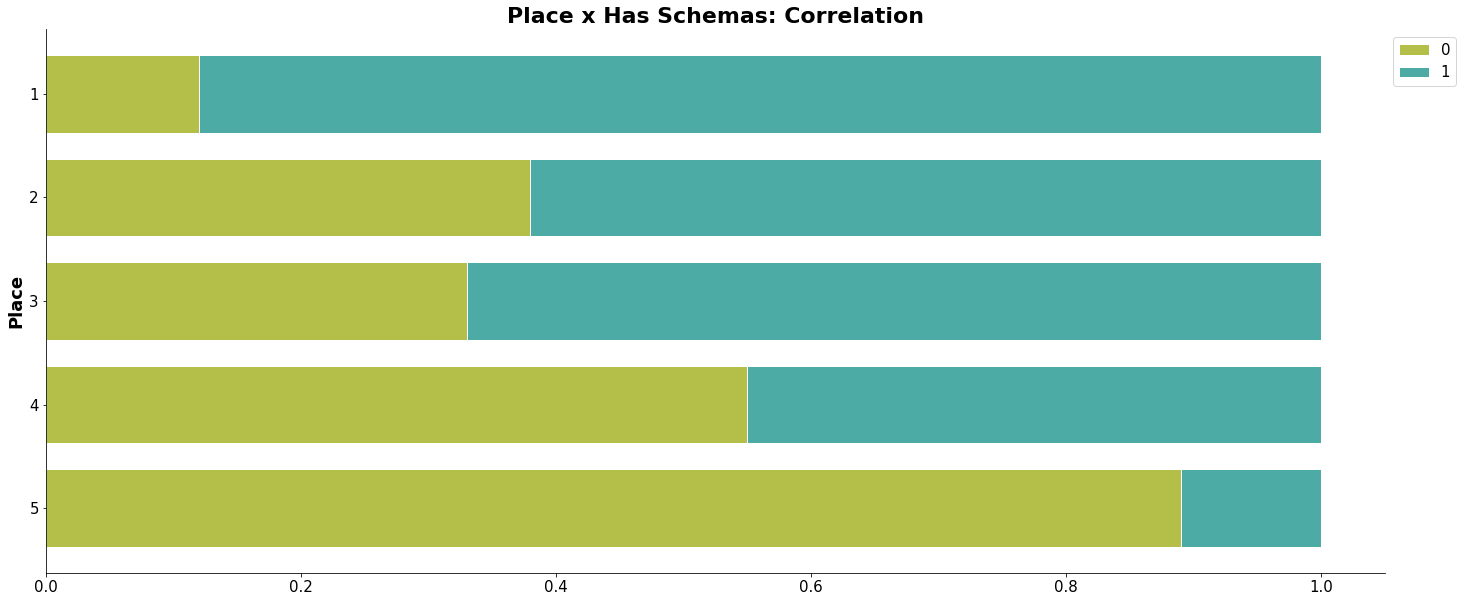

In [41]:
feature = "Has Schemas"

dt = stacked_data_prep(df, var=feature, split=False)

dt.plot(kind="barh", stacked=True, title="stacked", figsize=(24, 10),
        color = [my_colors[3], my_colors[2]], xlabel="Place", edgecolor='white', width=0.75)
plt.title(f"Place x {feature}: Correlation", weight="bold", size=22)
plt.ylabel("Place", size = 18, weight="bold")

ax = plt.gca()
ax.invert_yaxis()

sns.despine()

plt.legend(labels=[0, 1], loc='upper left', bbox_to_anchor=(1,1), ncol=1);
# plt.savefig('viz.png', dpi=300, transparent=True, bbox_inches="tight")

## 3.7 Finished Place x "Has Formulas"

By *formulas* I mean any mathematical algorithm or methodology that is either **new** (created by the authors) or **tweaked** in order to convey an information.

👑 Majority of the notebooks that ended up as being on the first places had at least one of this customized formula within them - this enters within the categories *innovation* but also *performance*, which from what I have seen boosts the overall "score" of a notebook, making it one of the winners.

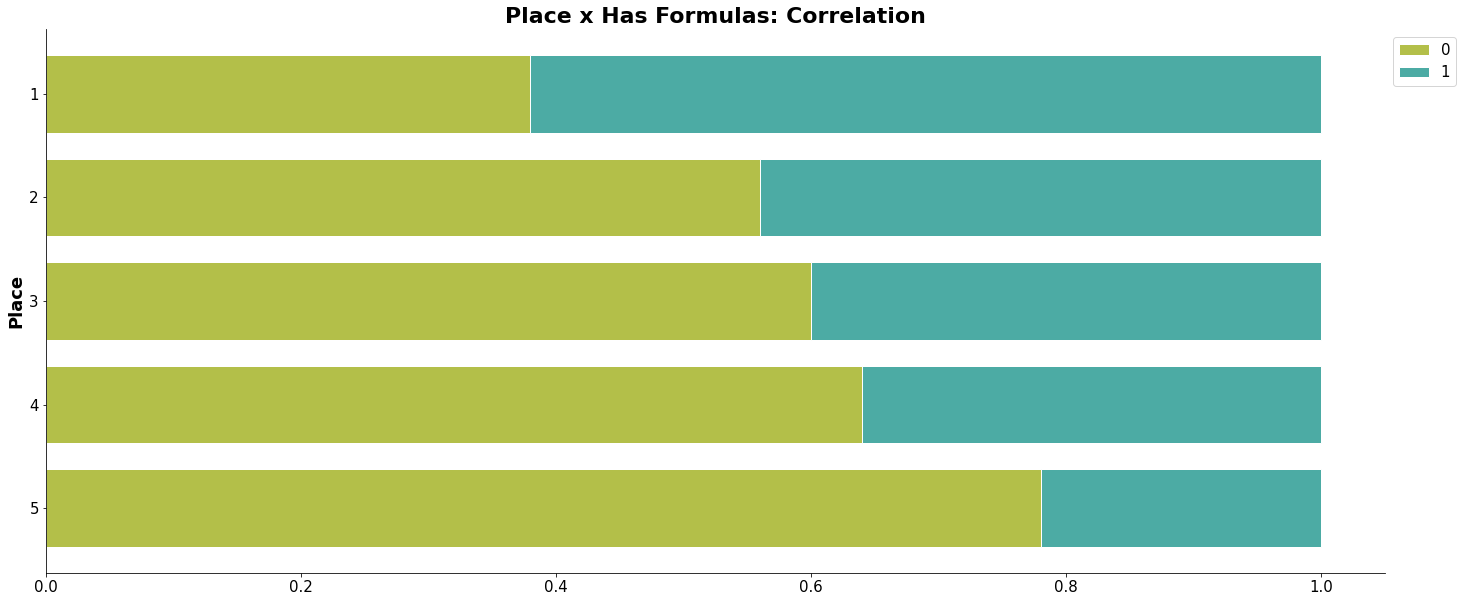

In [42]:
feature = "Has Formulas"

dt = stacked_data_prep(df, var=feature, split=False)

dt.plot(kind="barh", stacked=True, title="stacked", figsize=(24, 10),
        color = [my_colors[3], my_colors[2]], xlabel="Place", edgecolor='white', width=0.75)
plt.title(f"Place x {feature}: Correlation", weight="bold", size=22)
plt.ylabel("Place", size = 18, weight="bold")

ax = plt.gca()
ax.invert_yaxis()

sns.despine()

plt.legend(labels=[0, 1], loc='upper left', bbox_to_anchor=(1,1), ncol=1);
# plt.savefig('viz.png', dpi=300, transparent=True, bbox_inches="tight")

## 3.8 Finished Place x "GitHub/Repo"

There are a few notebooks (not many tho) who have the majority (or all) the analysis within a GitHub Repository. There is also one notebook that is formed by multiple notebooks - that contain an extanded and very thorough analysis.

👑 I wanted to see if these cases are more frequent for 1st places and **yes**. However, I would like to mention that repositories outside of Kaggle are usually and most frequently encountered within the NFL Competitions.

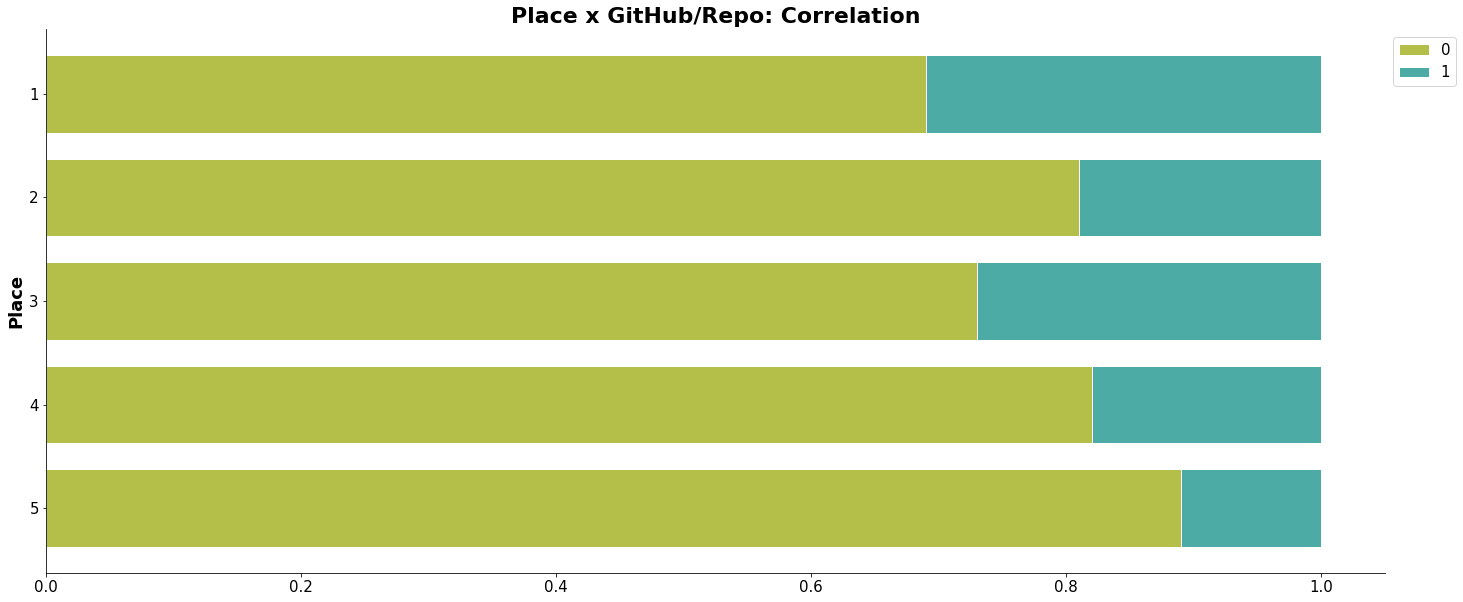

In [43]:
feature = "GitHub/Repo"

dt = stacked_data_prep(df, var=feature, split=False)

dt.plot(kind="barh", stacked=True, title="stacked", figsize=(24, 10),
        color = [my_colors[3], my_colors[2]], xlabel="Place", edgecolor='white', width=0.75)
plt.title(f"Place x {feature}: Correlation", weight="bold", size=22)
plt.ylabel("Place", size = 18, weight="bold")

ax = plt.gca()
ax.invert_yaxis()

sns.despine()

plt.legend(labels=[0, 1], loc='upper left', bbox_to_anchor=(1,1), ncol=1);
# plt.savefig('viz.png', dpi=300, transparent=True, bbox_inches="tight")

In [44]:
# 🐝
wandb.finish()

# 4. Conclusions

👑 Here are some of my main conclusions after I have looked at the entire data:
1. **Specialize on a typology of competition** - there are higher chances to win if you are an expert in the NFL play. As we've seen, people that win in this competition are highly knowledgable, so spending time understanding the game and what it needs the most takes time.
2. **Follow the competition guidelines before anything else** - however some guidelines matter more than others. From what I have seen a very good Performance or Reccomendation overpowers Clarity or Composition.
3. **Innovation and Complexity overpowers Cleanliness and Attention to Detail** - although I personaly have a very high attention to details, the truth of the matter is that the judges will most likely care about the outcome in itself, not necessarly of how it is presented. If you have a very good idea but you don't put it out there because it is not *polished*, think again and do it, you might have more to win than any other "polished" work. That being said, **the bar has been raised high** over the years, meaning that the notebooks are more and more structured and clean, so there might be expectations.
4. **Team number doesn't count** - however if you can team up with somebody that has already been active (and maybe won) in some of these previous competitions, the chances increase.
5. **Familiarize with R** - R isn't the go to from a development perspective, but it is quite prefered for Analytics Competitions, so it might be worth taking a look.
6. **The Power of Data Visualization** - dress to impress. There is great power in tools like plotly and D3.js.
7. **Use Schemas** - utilize the power of visualization to express your ideas. Use examples and the right colors, so that the viewer will understand 10 fold faster and better what you want to say.
8. **Create your own formulas** - this is used more and more within the winning Kaggle notebooks. Look at the data in an original manner and use math to create better meaning out of it.

<center><img src="https://i.imgur.com/0cx4xXI.png"></center>

### 🐝 W&B Dashboard

> My [W&B Dashboard](https://wandb.ai/andrada/RuleEmAll?workspace=user-andrada).

<center><video src="https://i.imgur.com/XJJsVNA.mp4" width=800 controls></center>

<center><img src="https://i.imgur.com/knxTRkO.png"></center>

### My Specs

* 🖥 Z8 G4 Workstation
* 💾 2 CPUs & 96GB Memory
* 🎮 2x NVIDIA A6000
* 💻 Zbook Studio G7 on the go